In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

In [5]:
df = pd.read_excel("stats output/merged_output_with_sv_stats.xlsx")

In [4]:
print("Shape:", df.shape)
print(df.head())

Shape: (21225, 32)
   SUBJECT_ID  HADM_ID  VISIT_ID    MONITORTIME  SV1_min  SV1_max   SV1_mean  \
0           4   102191         1  9/25/81 18:40     67.0     95.0  77.461538   
1           4   102191         1  9/25/81 19:45     73.0     92.0  80.846154   
2           4   102191         1  9/25/81 20:50     70.0    116.0  91.461538   
3           4   102191         1  9/25/81 21:55     83.0     95.0  88.000000   
4          37   102040         1  8/12/71 11:00     70.0     99.0  84.928571   

   SV1_median  SV2_min  SV2_max  ...  SV5_mean  SV5_median  SV6_min  SV6_max  \
0        74.0     68.0     97.0  ...       NaN         NaN      NaN      NaN   
1        82.0     74.0     92.0  ...       NaN         NaN      NaN      NaN   
2        86.0     10.0     99.0  ...       NaN         NaN      NaN      NaN   
3        86.0     83.0     99.0  ...       NaN         NaN      NaN      NaN   
4        84.0     71.0    100.0  ...       NaN         NaN     16.0     26.0   

    SV6_mean  SV6_m

In [26]:

# Identify SV feature columns
sv_cols = [c for c in df.columns if "SV" in c]
mean_cols = [c for c in sv_cols if "mean" in c]
min_cols  = [c for c in sv_cols if c.endswith("_min")]
max_cols  = [c for c in sv_cols if c.endswith("_max")]
med_cols  = [c for c in sv_cols if c.endswith("_median")]

print("SV columns:", sv_cols)


SV columns: ['SV1_min', 'SV1_max', 'SV1_mean', 'SV1_median', 'SV2_min', 'SV2_max', 'SV2_mean', 'SV2_median', 'SV3_min', 'SV3_max', 'SV3_mean', 'SV3_median', 'SV4_min', 'SV4_max', 'SV4_mean', 'SV4_median', 'SV5_min', 'SV5_max', 'SV5_mean', 'SV5_median', 'SV6_min', 'SV6_max', 'SV6_mean', 'SV6_median', 'SV7_min', 'SV7_max', 'SV7_mean', 'SV7_median', 'SV1_range']


📊 1️⃣ Missingness Plot

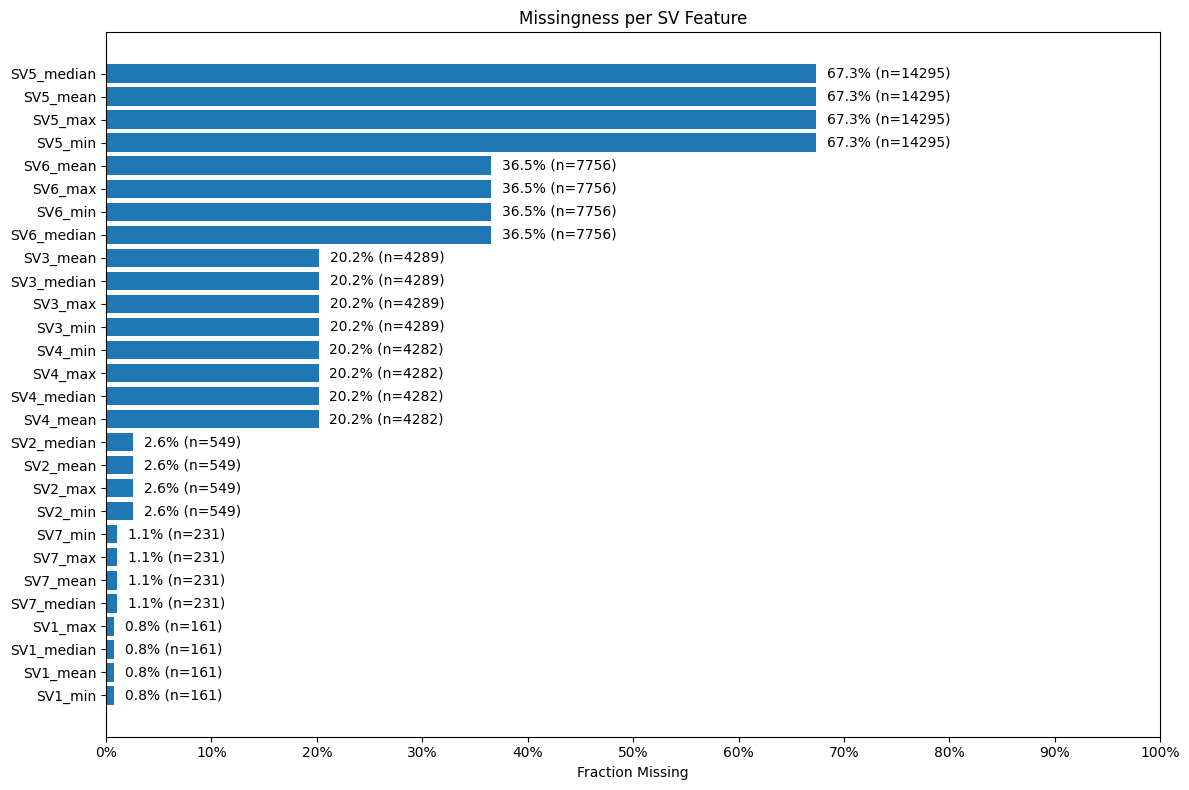

In [ ]:

# Compute missing stats
missing_frac = df[sv_cols].isna().mean()
missing_count = df[sv_cols].isna().sum()
total_rows = len(df)

# Sort by missing fraction
missing_frac = missing_frac.sort_values(ascending=False)
missing_count = missing_count[missing_frac.index]

# Plot
plt.figure(figsize=(12, 8))

bars = plt.barh(missing_frac.index, missing_frac.values)

plt.xlabel("Fraction Missing")
plt.title("Missingness per SV Feature")
plt.gca().invert_yaxis()  # highest missing on top

# ---- FORMAT X AXIS AS 10%, 20%, 30% ----
plt.xlim(0, 1)
plt.xticks(np.arange(0, 1.1, 0.1))  # ticks every 10%
plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))  # convert to %

# Add annotations
for i, (frac, count) in enumerate(zip(missing_frac.values, missing_count.values)):
    plt.text(frac + 0.01, i,
             f"{frac*100:.1f}% (n={count})",
             va='center')

plt.tight_layout()
plt.show()


Which SV has highest missing?

Are some vitals rarely recorded?

📊 2️⃣ Distribution of SV Means (Boxplots)

/var/folders/6c/h_2qq_495412tl4y7hpdmk5c0000gn/T/ipykernel_11382/2255159374.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col].dropna() for col in mean_cols],


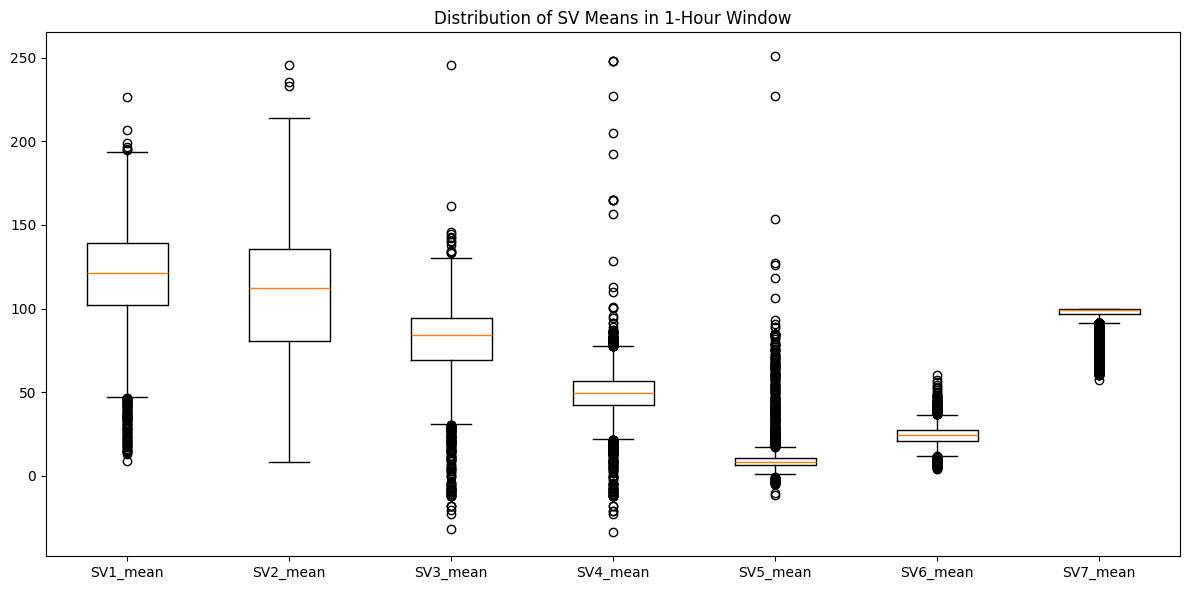

In [45]:
plt.figure(figsize=(12,6))
plt.boxplot([df[col].dropna() for col in mean_cols],
            labels=mean_cols,
            vert=True)

plt.xticks()
plt.title("Distribution of SV Means in 1-Hour Window")
plt.tight_layout()
#plt.savefig("sv_means_boxplot.png", dpi=200)
plt.show()


Are distributions skewed?

Are there extreme outliers?

Which SV shows highest variability?

📊 3️⃣ Correlation Heatmap (Pure Matplotlib)

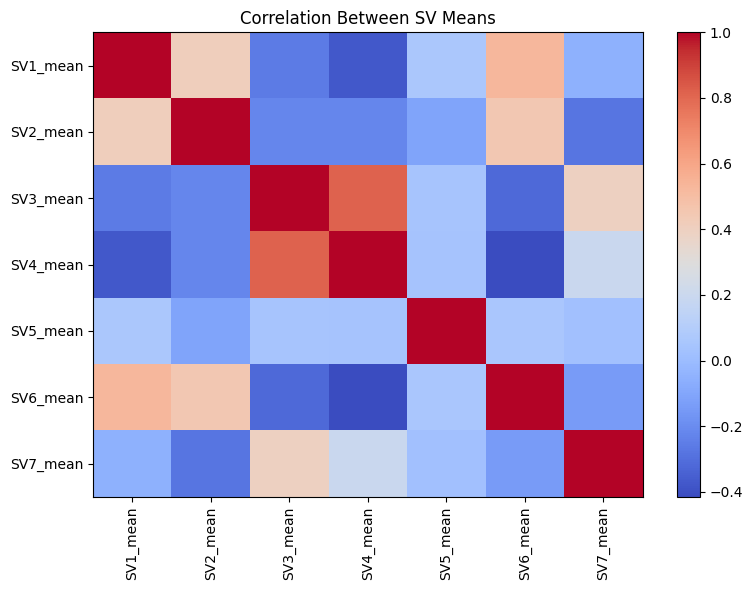

In [47]:
corr = df[mean_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()

plt.xticks(range(len(mean_cols)), mean_cols, rotation=90)
plt.yticks(range(len(mean_cols)), mean_cols)

plt.title("Correlation Between SV Means")
plt.tight_layout()
#plt.savefig("correlation_heatmap.png", dpi=200)
plt.show()


Strong correlations?

Redundant features?

Physiological coupling?

Patient Trend (Temporal Analysis)

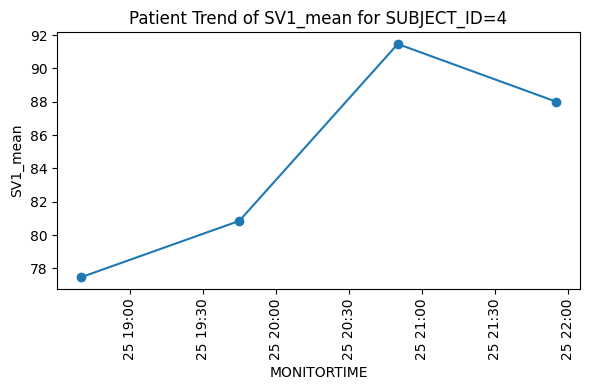

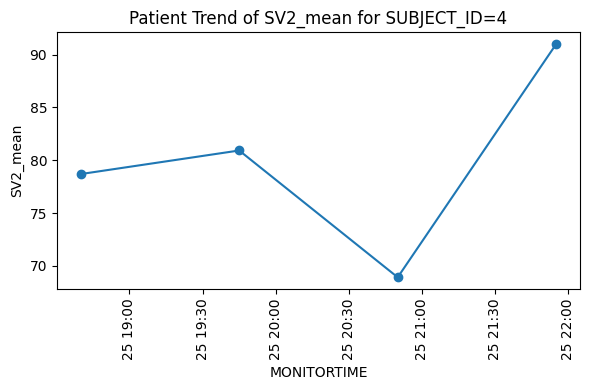

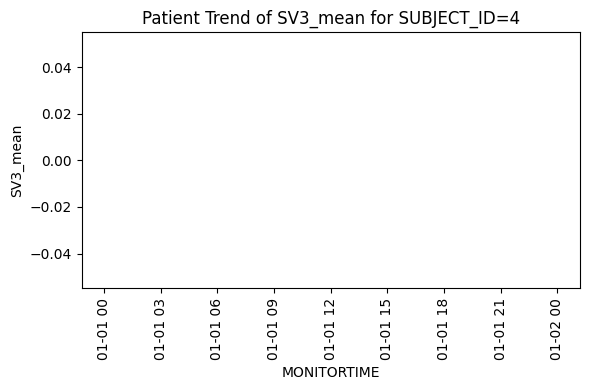

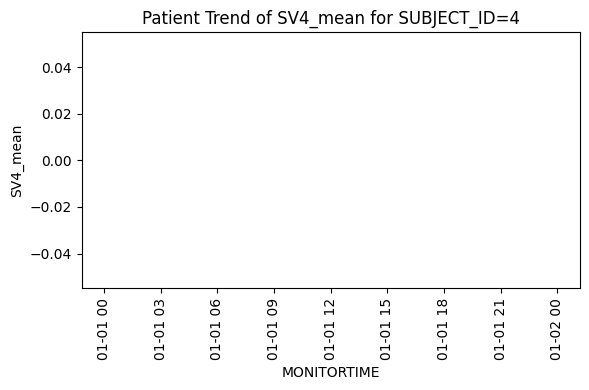

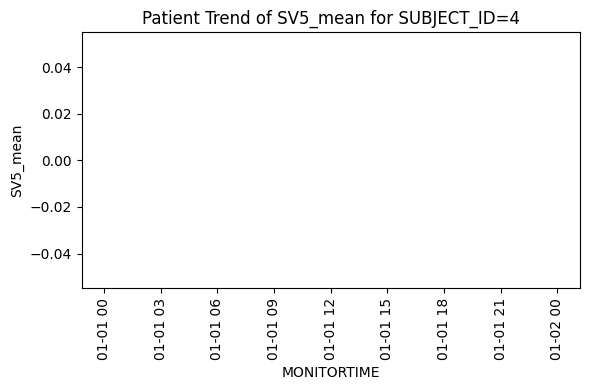

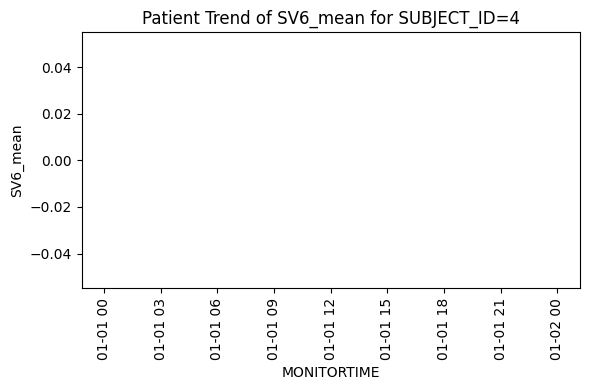

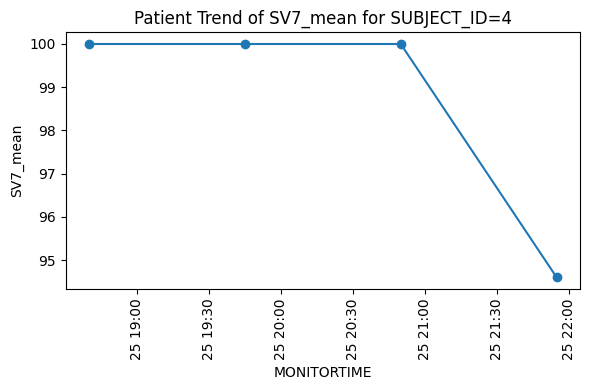

In [50]:
# Convert to datetime if needed
if "MONITORTIME" in df.columns:
    df["MONITORTIME"] = pd.to_datetime(df["MONITORTIME"], errors="coerce")

# Pick one patient

example_subject = df.iloc[0]["SUBJECT_ID"]
example_df = df[df["SUBJECT_ID"] == example_subject].sort_values("MONITORTIME")

mean_cols = [f"SV{i}_mean" for i in range(1, 8)]
mean_cols = [c for c in mean_cols if c in example_df.columns]

for col in mean_cols:
    plt.figure(figsize=(6, 4))
    plt.plot(example_df["MONITORTIME"], example_df[col], marker="o")
    plt.xticks(rotation=90)
    plt.title(f"Patient Trend of {col} for SUBJECT_ID={example_subject}")
    plt.xlabel("MONITORTIME")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


Stable vs fluctuating patterns?

Sudden spikes?

Variability Feature

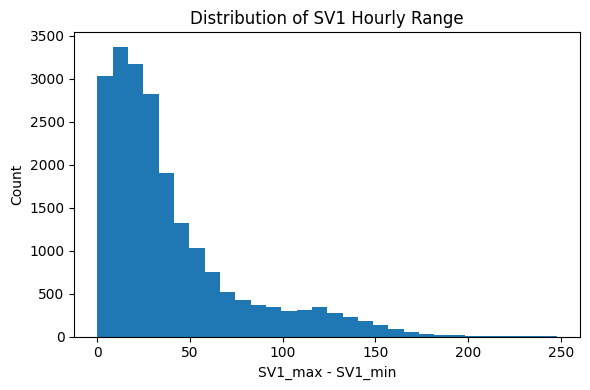

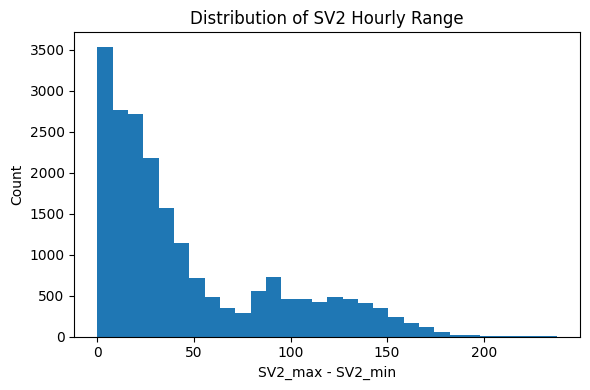

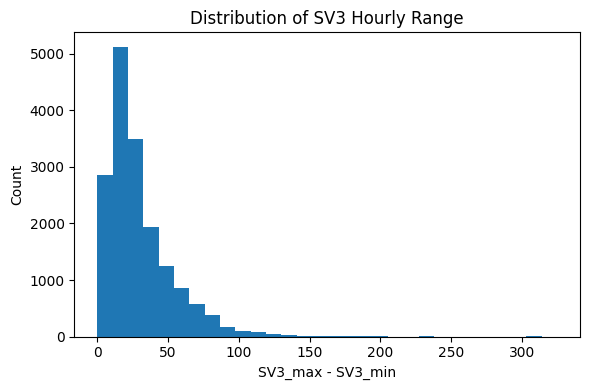

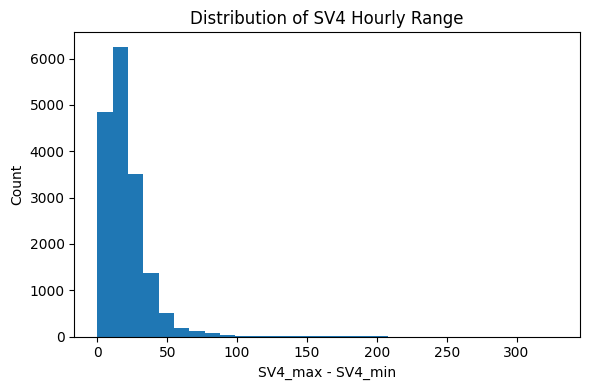

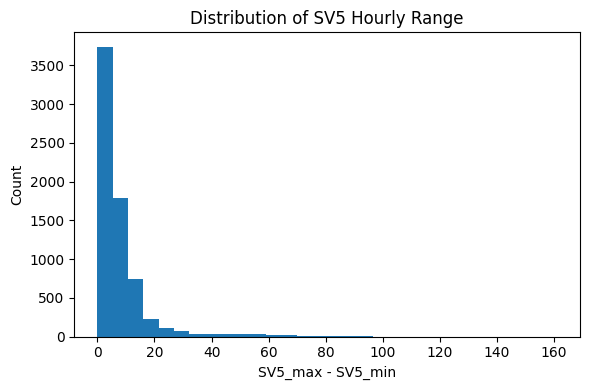

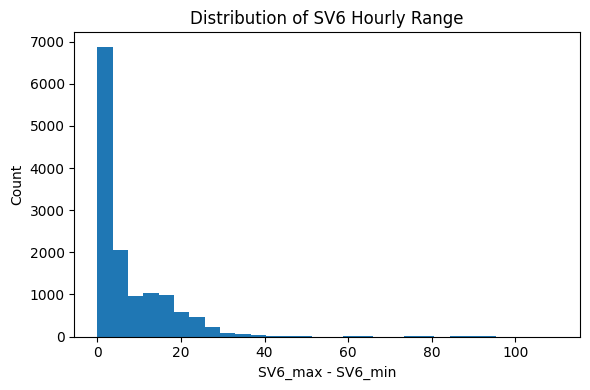

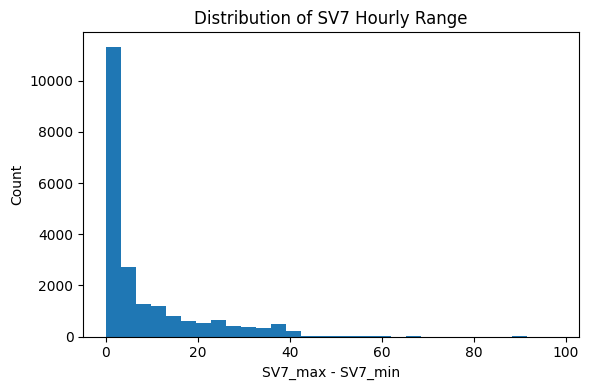

In [36]:
import matplotlib.pyplot as plt

for sv in range(1, 8):  # SV1 to SV7
    max_col = f"SV{sv}_max"
    min_col = f"SV{sv}_min"
    range_col = f"SV{sv}_range"

    if max_col in df.columns and min_col in df.columns:
        df[range_col] = df[max_col] - df[min_col]

        plt.figure(figsize=(6, 4))
        plt.hist(df[range_col].dropna(), bins=30)
        plt.title(f"Distribution of SV{sv} Hourly Range")
        plt.xlabel(f"SV{sv}_max - SV{sv}_min")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    else:
        print(f"Skipping SV{sv}: missing {max_col} or {min_col}")


Outlier rate per feature

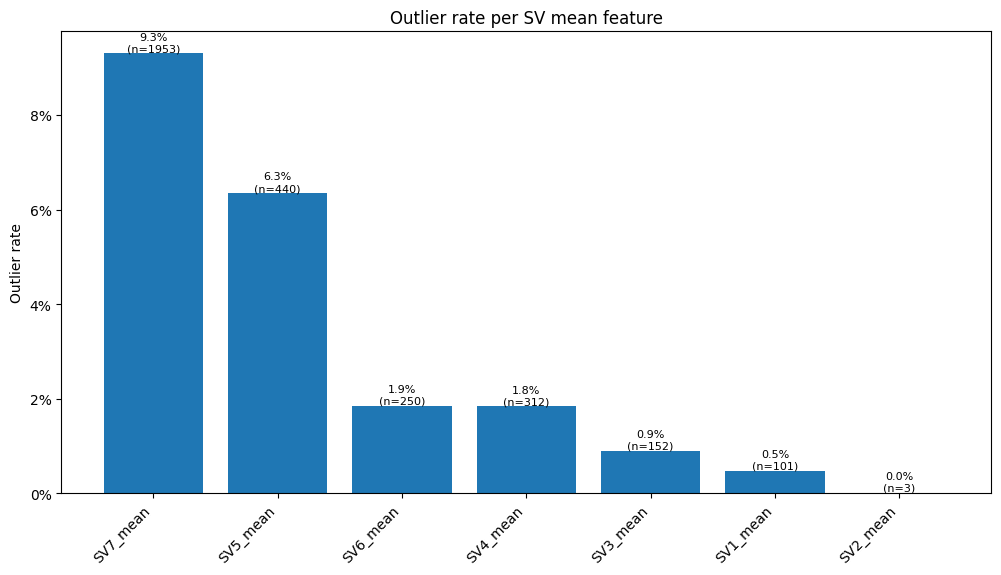

In [51]:
def outlier_rate_iqr(series):
    s = series.dropna()
    if len(s) < 10:
        return np.nan, 0
    q1, q3 = np.percentile(s, [25, 75])
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    out = ((s < lo) | (s > hi)).sum()
    return out / len(s), int(out)

out_rates = []
for col in mean_cols:
    rate, out = outlier_rate_iqr(df[col])
    out_rates.append((col, rate, out))

out_df = pd.DataFrame(out_rates, columns=["feature", "outlier_rate", "outlier_count"]).sort_values("outlier_rate", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(out_df["feature"], out_df["outlier_rate"])
plt.xticks(rotation=45, ha="right")
plt.gca().yaxis.set_major_formatter(lambda x, _: f"{x*100:.0f}%")
plt.title("Outlier rate per SV mean feature")
plt.ylabel("Outlier rate")
# annotate counts
for i, (feat, rate, cnt) in enumerate(out_df.values):
    plt.text(i, rate, f"{rate*100:.1f}%\n(n={cnt})", ha="center", va="bottom", fontsize=8)


Session density: rows per visit

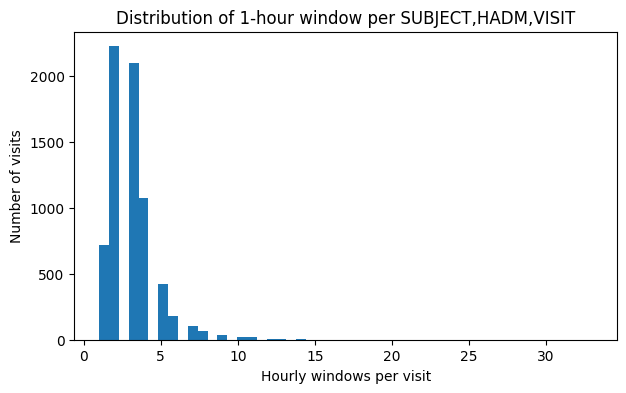

In [53]:
key_cols = [c for c in ["SUBJECT_ID","HADM_ID","VISIT_ID"] if c in df.columns]
if len(key_cols) == 3:
    counts = df.groupby(key_cols).size()
    plt.figure(figsize=(7,4))
    plt.hist(counts.values, bins=50)
    plt.title("Distribution of 1-hour window per SUBJECT,HADM,VISIT")
    plt.xlabel("Hourly windows per visit")
    plt.ylabel("Number of visits")


Missingness by patient/visit (how many SV means missing per row)

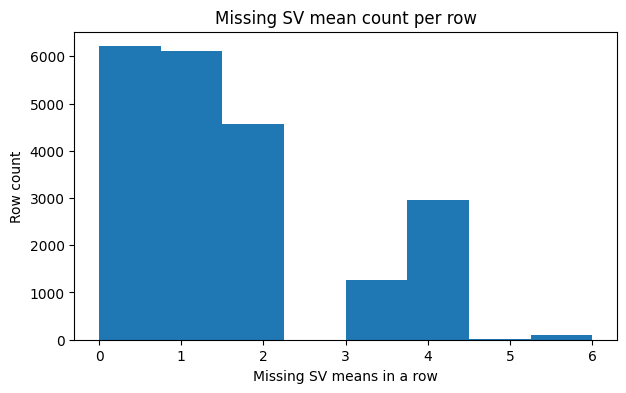

In [54]:
if mean_cols:
    df["missing_svmean_per_row"] = df[mean_cols].isna().sum(axis=1)
    plt.figure(figsize=(7,4))
    plt.hist(df["missing_svmean_per_row"].dropna(), bins=len(mean_cols)+1)
    plt.title("Missing SV mean count per row")
    plt.xlabel("Missing SV means in a row")
    plt.ylabel("Row count")

In [5]:
df.head()

,SUBJECT_ID,HADM_ID,VISIT_ID,MONITORTIME,SV1_min,SV1_max,SV1_mean,SV1_median,SV2_min,SV2_max,...,SV5_mean,SV5_median,SV6_min,SV6_max,SV6_mean,SV6_median,SV7_min,SV7_max,SV7_mean,SV7_median
0,4,102191,1,9/25/81 18:40,67.0,95.0,77.461538,74.0,68.0,97.0,...,NaN,NaN,NaN,NaN,NaN,NaN,100.0,100.0,100.000000,100.0
1,4,102191,1,9/25/81 19:45,73.0,92.0,80.846154,82.0,74.0,92.0,...,NaN,NaN,NaN,NaN,NaN,NaN,100.0,100.0,100.000000,100.0
2,4,102191,1,9/25/81 20:50,70.0,116.0,91.461538,86.0,10.0,99.0,...,NaN,NaN,NaN,NaN,NaN,NaN,100.0,100.0,100.000000,100.0
3,4,102191,1,9/25/81 21:55,83.0,95.0,88.000000,86.0,83.0,99.0,...,NaN,NaN,NaN,NaN,NaN,NaN,73.0,100.0,94.600000,100.0
4,37,102040,1,8/12/71 11:00,70.0,99.0,84.928571,84.0,71.0,100.0,...,NaN,NaN,16.0,26.0,18.916667,16.0,98.0,100.0,99.538462,100.0


In [6]:
samples_per_patient = (
    df.groupby(['SUBJECT_ID', 'HADM_ID', 'VISIT_ID'])
      .size()
)

print("Average:", samples_per_patient.mean())
print("Median:", samples_per_patient.median())
print("Min:", samples_per_patient.min())
print("Max:", samples_per_patient.max())

Average: 3.0417024935511607
Median: 3.0
Min: 1
Max: 33
